Part 1: Data Loading and Exploration
Loading the KDD Cup 99 dataset and examining network traffic patterns

In [10]:
# Imports
import pandas as pd
import numpy as np
import warnings
import os

warnings.filterwarnings("ignore")

# Confirm working directory and available files
print("Working directory:", os.getcwd())
print("Files in directory:", os.listdir())

# Column names for KDD Cup 99 dataset (CSV has NO header)
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label"
]

# LOAD DATASET
# The actual filename on disk is: kddcup_data.csv
df = pd.read_csv(r"C:\Aicybersec\kddcup_data.csv", names=columns)

# Remove trailing period from labels (KDD Cup quirk)
df["label"] = df["label"].str.strip(".")

# ===============================
# Sanity Checks / Exploration
# ===============================

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nLabel distribution (top 10):")
print(df["label"].value_counts().head(10))

print("\nData types summary:")
print(df.dtypes.value_counts())

Working directory: C:\AIcybersec
Files in directory: ['.ipynb_checkpoints', 'cybersec_env', 'jupyter_config', 'jupyter_runtime', 'kddcup_data.csv', 'Lab2_Spam_Detection.ipynb', 'malware_rf_model.joblib', 'MediaCreationTool_22H2.exe', 'spam.csv.csv', 'Untitled.ipynb', 'Week1_Lab_Malware_Detection.ipynb']

Dataset shape:
(4898431, 42)

First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,215,45076,0,0,0,0,...,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,normal
1,0,tcp,http,SF,162,4528,0,0,0,0,...,1,1.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,normal
2,0,tcp,http,SF,236,1228,0,0,0,0,...,2,1.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,normal
3,0,tcp,http,SF,233,2032,0,0,0,0,...,3,1.0,0.0,0.33,0.0,0.0,0.0,0.0,0.0,normal
4,0,tcp,http,SF,239,486,0,0,0,0,...,4,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,normal



Label distribution (top 10):
label
smurf          2807886
neptune        1072017
normal          972781
satan            15892
ipsweep          12481
portsweep        10413
nmap              2316
back              2203
warezclient       1020
teardrop           979
Name: count, dtype: int64

Data types summary:
int64      23
float64    15
str         4
Name: count, dtype: int64


 Part 2: Feature Engineering
Converting categorical features with one-hot encoding

In [12]:
# ===============================
# Part 2: Feature Engineering
# One-Hot Encoding Categorical Features
# ===============================

# Identify categorical columns
categorical_cols = ["protocol_type", "service", "flag"]

print("Categorical features and number of unique values:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nOriginal number of features:", len(df.columns))
print("After one-hot encoding:", len(df_encoded.columns))

# Separate features and target
X = df_encoded.drop("label", axis=1)
y = df_encoded["label"]

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Categorical features and number of unique values:
protocol_type: 3 unique values
service: 70 unique values
flag: 11 unique values

Original number of features: 42
After one-hot encoding: 120

Feature matrix shape: (4898431, 119)
Target vector shape: (4898431,)


Part 3: Train-Test Split
Splitting data with stratification to maintain class balance

In [14]:
from sklearn.model_selection import train_test_split
import numpy as np

# Create binary target: 0 = normal, 1 = attack
# KDD Cup 99 uses 'normal' as the normal class; everything else is an attack
y_binary = (y != "normal").astype(int)

# Train-test split with stratification to maintain normal vs attack ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.3,
    random_state=42,
    stratify=y_binary
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining set attack rate: {y_train.mean():.2%}")
print(f"Test set attack rate: {y_test.mean():.2%}")

Training set: 3428901 samples
Test set: 1469530 samples

Training set attack rate: 80.14%
Test set attack rate: 80.14%


 Part 4: Model Training
Training a Random Forest classifier for intrusion detection

In [15]:
from sklearn.ensemble import RandomForestClassifier
import time
# Initialize Random Forest
clf = RandomForestClassifier(
n_estimators=100, # 100 decision trees
max_depth=20, # Limit tree depth to prevent overfitting
random_state=42,
n_jobs=-1, # Use all CPU cores
verbose=1 # Show progress
)
# Train and time
print('Training Random Forest...')
start_time = time.time()
clf.fit(X_train, y_train)
training_time = time.time() - start_time
print(f'\nTraining completed in {training_time:.2f} seconds')
print('Model ready for predictions!')

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   42.0s finished



Training completed in 45.13 seconds
Model ready for predictions!


Part 5: Model Evaluation
Assessing IDS performance with comprehensive metrics

In [17]:
# ===============================
# Part 5: Model Evaluation
# ===============================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Make predictions
y_pred = clf.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal (0)", "Attack (1)"]
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Extract confusion matrix values
tn, fp, fn, tp = cm.ravel()

print(f"\nTN={tn}, FP={fp}, FN={fn}, TP={tp}")

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    1.7s finished


Overall Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00    291834
  Attack (1)       1.00      1.00      1.00   1177696

    accuracy                           1.00   1469530
   macro avg       1.00      1.00      1.00   1469530
weighted avg       1.00      1.00      1.00   1469530


Confusion Matrix:
[[ 291827       7]
 [     61 1177635]]

TN=291827, FP=7, FN=61, TP=1177635


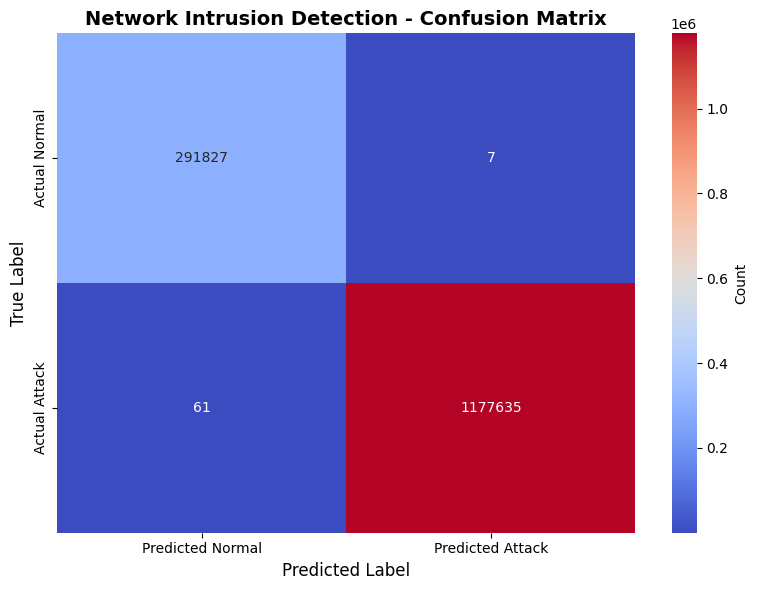

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
xticklabels=['Predicted Normal', 'Predicted Attack'],
yticklabels=['Actual Normal', 'Actual Attack'],
cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Network Intrusion Detection - Confusion Matrix', fontsize=14,
fontweight='bold')
plt.tight_layout()
plt.show()

Part 6: Feature Importance
Identifying which network features best indicate attacks

Top 15 Most Important Features:
                    feature  importance
                  dst_bytes    0.125893
                      count    0.125688
               service_http    0.080603
                  logged_in    0.072499
                  src_bytes    0.055564
dst_host_srv_diff_host_rate    0.045400
                  srv_count    0.044599
              service_ecr_i    0.043061
             dst_host_count    0.042522
              same_srv_rate    0.039860
dst_host_same_src_port_rate    0.039407
     dst_host_diff_srv_rate    0.032090
         dst_host_srv_count    0.032070
         srv_diff_host_rate    0.026717
          protocol_type_tcp    0.026148


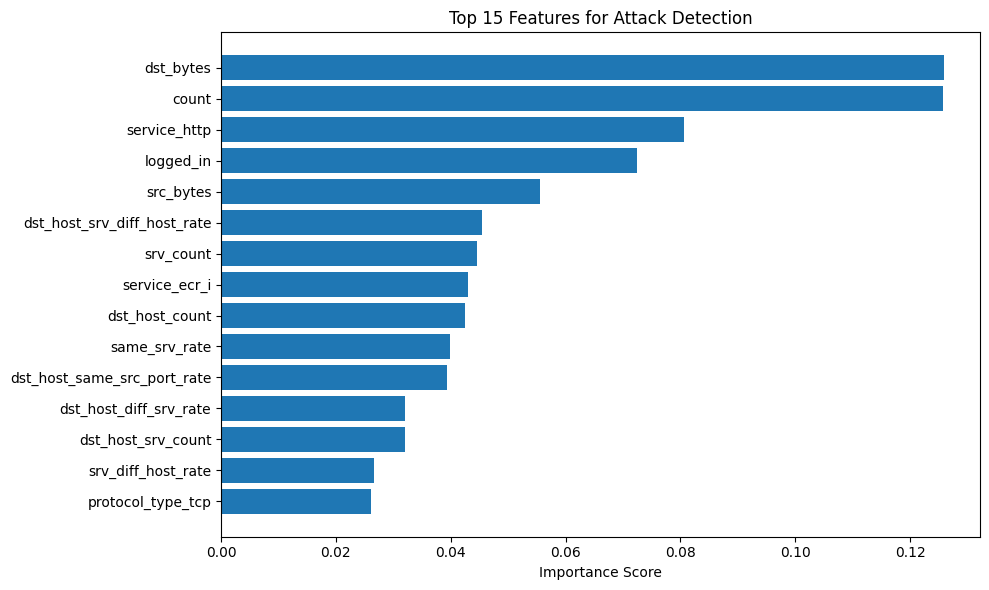

In [19]:
# Get feature importances
feature_importance = pd.DataFrame({
'feature': X.columns,
'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
# Top 15 features
top_features = feature_importance.head(15)
print('Top 15 Most Important Features:')
print(top_features.to_string(index=False))
# Visualize
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score')
plt.title('Top 15 Features for Attack Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Part 7: Advanced Experiments
Dimensionality reduction and algorithm comparison

In [20]:
from sklearn.decomposition import PCA
# Reduce to 20 principal components
pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print(f'Explained variance: {pca.explained_variance_ratio_.sum():.2%}')
# Train on reduced features
clf_pca = RandomForestClassifier(n_estimators=100, random_state=42,
n_jobs=-1)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
print(f'PCA Model Accuracy: {accuracy_score(y_test, y_pred_pca):.4f}')

Explained variance: 100.00%
PCA Model Accuracy: 1.0000


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Sample a smaller subset for faster training
sample_size = 10000
X_sample = X_train[:sample_size]
y_sample = y_train[:sample_size]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50)
}

for name, model in models.items():
    model.fit(X_sample, y_sample)
    y_pred_model = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_model)
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9958
Gradient Boosting: 0.9992
